## Domain: Semiconductor Manufacturing Process

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB 
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
import warnings
from sklearn import svm
warnings.filterwarnings('ignore')
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import accuracy_score
import pickle
from sklearn.model_selection import LeaveOneOut

from sklearn.linear_model import LogisticRegression
from scipy.stats import zscore

from sklearn.model_selection import StratifiedKFold

pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)


%matplotlib inline

### 1.Import and understand the data.

**A. Import ‘signal-data.csv’ as DataFrame.**


In [2]:
data=pd.read_csv("signal-data.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1567 entries, 0 to 1566
Columns: 592 entries, Time to Pass/Fail
dtypes: float64(590), int64(1), object(1)
memory usage: 7.1+ MB


**B. Print 5 point summary and share at least 2 observations.**

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
0,1561.0,3014.452896,73.621787,2743.2400,2966.260000,3011.49000,3056.650000,3356.3500
1,1560.0,2495.850231,80.407705,2158.7500,2452.247500,2499.40500,2538.822500,2846.4400
2,1553.0,2200.547318,29.513152,2060.6600,2181.044400,2201.06670,2218.055500,2315.2667
3,1553.0,1396.376627,441.691640,0.0000,1081.875800,1285.21440,1591.223500,3715.0417
4,1553.0,4.197013,56.355540,0.6815,1.017700,1.31680,1.525700,1114.5366
5,1553.0,100.000000,0.000000,100.0000,100.000000,100.00000,100.000000,100.0000
6,1553.0,101.112908,6.237214,82.1311,97.920000,101.51220,104.586700,129.2522
7,1558.0,0.121822,0.008961,0.0000,0.121100,0.12240,0.123800,0.1286
8,1565.0,1.462862,0.073897,1.1910,1.411200,1.46160,1.516900,1.6564
9,1565.0,-0.000841,0.015116,-0.0534,-0.010800,-0.00130,0.008400,0.0749


Observations:
- Most of the features have null values
- Many columns have standard deviation=0 which means the values are same in all the rows for the column
- Column "161" has the maximum standard deviation of "4239.245058"
- Most of the features have a different mean and median(50th percentile) which means that the distributions are mostly to be skewed.
- The difference between (Q1 and min) or (Q3 and max) is very high so there could be outliers


### 2. Data cleansing

**A. Write a for loop which will remove all the features with 20%+ Null values and impute rest with mean of the feature.**

In [5]:
percentage=0
count=0
for i in data.columns:
    percentage=(data[i].isnull().sum()/data.shape[0])*100
    if percentage >=20:
        data.drop(i,axis=1,inplace=True)
        count=count+1  
        print("Percentage of missing values is greater than 20 in column: ",i," hence dropping the column")
print("Number of columns removed ",count)

Percentage of missing values is greater than 20 in column:  72  hence dropping the column
Percentage of missing values is greater than 20 in column:  73  hence dropping the column
Percentage of missing values is greater than 20 in column:  85  hence dropping the column
Percentage of missing values is greater than 20 in column:  109  hence dropping the column
Percentage of missing values is greater than 20 in column:  110  hence dropping the column
Percentage of missing values is greater than 20 in column:  111  hence dropping the column
Percentage of missing values is greater than 20 in column:  112  hence dropping the column
Percentage of missing values is greater than 20 in column:  157  hence dropping the column
Percentage of missing values is greater than 20 in column:  158  hence dropping the column
Percentage of missing values is greater than 20 in column:  220  hence dropping the column
Percentage of missing values is greater than 20 in column:  244  hence dropping the column
Pe

In [6]:
#Imputing the missing values with the mean of the column
for i in data.columns:
    if(i!="Time"):
        data[i].fillna(value=data[i].mean(), inplace=True)

In [7]:
data.shape

(1567, 560)

**B. Identify and drop the features which are having same value for all the rows.**

In [8]:
count=0
for i in data.columns:
    if data[i].dtype!='O':
        if data[i].std()==0:
            count=count+1
            data.drop(i,axis=1,inplace=True)
            print("Removed column: ",i," since the values are the same")
print("No of rows having same are: ",count)

Removed column:  5  since the values are the same
Removed column:  13  since the values are the same
Removed column:  42  since the values are the same
Removed column:  49  since the values are the same
Removed column:  52  since the values are the same
Removed column:  69  since the values are the same
Removed column:  97  since the values are the same
Removed column:  141  since the values are the same
Removed column:  149  since the values are the same
Removed column:  178  since the values are the same
Removed column:  179  since the values are the same
Removed column:  186  since the values are the same
Removed column:  189  since the values are the same
Removed column:  190  since the values are the same
Removed column:  191  since the values are the same
Removed column:  192  since the values are the same
Removed column:  193  since the values are the same
Removed column:  194  since the values are the same
Removed column:  226  since the values are the same
Removed column:  229

In [9]:
data.shape

(1567, 444)

**C. Drop other features if required using relevant functional knowledge. Clearly justify the same.**

In [10]:
#Dropping the timestamp because that is unique across almost all entries.
print("No of unique entries in Time column is ",data["Time"].nunique())
print("No of rows in the dataset is ",data.shape[0])

No of unique entries in Time column is  1534
No of rows in the dataset is  1567


In [11]:
print("Repetiton of entries for the value count is ",data["Time"].value_counts())

Repetiton of entries for the value count is  2008-10-15 01:52:00    3
2008-05-08 07:12:00    2
2008-09-30 19:17:00    2
2008-09-18 03:58:00    2
2008-08-21 19:12:00    2
2008-07-27 22:28:00    2
2008-08-23 05:58:00    2
2008-08-29 07:33:00    2
2008-08-30 05:05:00    2
2008-09-13 16:04:00    2
2008-03-09 18:16:00    2
2008-10-16 02:16:00    2
2008-10-13 15:42:00    2
2008-09-23 06:44:00    2
2008-09-14 18:27:00    2
2008-10-15 02:40:00    2
2008-02-09 03:35:00    2
2008-02-09 01:10:00    2
2008-05-10 00:33:00    2
2008-08-19 05:11:00    2
2008-08-23 05:57:00    2
2008-08-29 05:57:00    2
2008-08-29 05:54:00    2
2008-08-19 11:13:00    2
2008-08-22 09:29:00    2
2008-03-10 19:23:00    2
2008-08-31 10:59:00    2
2008-06-10 17:26:00    2
2008-10-16 04:02:00    2
2008-02-10 23:32:00    2
2008-08-19 18:12:00    2
2008-08-19 18:30:00    2
2008-09-24 12:04:00    1
2008-09-24 02:44:00    1
2008-09-24 06:13:00    1
2008-09-24 05:22:00    1
2008-09-24 05:13:00    1
2008-09-25 02:03:00    1
2008-

Observations on the column "Time"

- From the 1567 entries for the time column 1534 entries are unique.
- Maximum repetition for the time column is only 2.

So it is better to remove the Time column from the dataset

In [12]:
data.drop("Time",axis=1,inplace=True)

In [13]:
data.shape

(1567, 443)

In [14]:
data.columns

Index(['0', '1', '2', '3', '4', '6', '7', '8', '9', '10',
       ...
       '577', '582', '583', '584', '585', '586', '587', '588', '589',
       'Pass/Fail'],
      dtype='object', length=443)

In [15]:
data.head(20)

,0,1,2,3,4,6,7,8,9,10,11,12,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,46,47,48,50,51,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,70,71,74,75,76,77,78,79,80,81,82,83,84,86,87,88,89,90,91,92,93,94,95,96,98,99,100,101,102,103,104,105,106,107,108,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,142,143,144,145,146,147,148,150,151,152,153,154,155,156,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,180,181,182,183,184,185,187,188,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,221,222,223,224,225,227,228,238,239,248,249,250,251,252,253,254,255,267,268,269,270,271,272,273,274,275,277,278,279,280,281,282,283,285,286,287,288,289,290,291,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,316,317,318,319,320,321,323,324,331,332,333,334,335,336,337,338,339,340,341,342,343,344,347,348,349,350,351,352,353,354,355,356,357,359,360,361,362,363,365,366,367,368,376,377,386,387,388,389,390,391,392,393,405,406,407,408,409,410,411,412,413,415,416,417,418,419,420,421,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,452,453,454,455,456,457,459,460,467,468,469,470,471,472,473,474,475,476,477,478,479,480,482,483,484,485,486,487,488,489,490,491,493,494,495,496,497,499,500,510,511,520,521,522,523,524,525,526,527,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,582,583,584,585,586,587,588,589,Pass/Fail
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,7.9558,414.8710,10.0433,0.9680,192.3963,12.5190,1.4026,-5419.00,2916.50,-4043.75,751.00,0.8955,1.7730,3.0490,64.2333,2.0222,0.1632,3.5191,83.3971,9.5126,50.6170,64.2588,49.3830,66.3141,86.9555,117.5132,61.290,4.5150,352.7173,10.1841,130.3691,723.3092,1.3072,141.2282,624.3145,218.3174,4.592,4.841,2834.0,0.9317,0.9484,4.7057,-1.7264,350.9264,10.6231,108.6427,16.1445,21.7264,29.5367,693.7724,0.9226,148.6009,608.1700,84.0793,0.0,0.0126,-0.0206,0.0141,-0.0307,-0.0083,-0.0026,-0.0567,-0.0044,7.2163,0.1320,2.3895,0.9690,1747.6049,0.1841,8671.9301,-0.3274,-0.0055,-0.0001,0.0001,0.0003,-0.2786,0.3974,-0.0251,0.0002,0.0002,0.1350,-0.0042,0.0003,0.0056,0.0000,-0.2468,0.3196,0.9460,0.0,748.6115,0.9908,58.4306,0.6002,0.9804,6.3788,15.88,2.639,15.94,15.93,0.8656,3.353,0.4098,3.188,-0.0473,0.7243,0.9960,2.2967,1000.7263,39.2373,123.0,111.3,75.2,46.2000,350.6710,0.3948,6.78,0.0034,0.0898,0.0850,0.0358,0.0328,12.2566,4.271,10.284,0.4734,0.0167,11.8901,0.41,0.0506,1017.0,967.0,1066.0,368.0,0.090,0.048,0.095,2.0,0.9,0.069,0.046,0.7250,0.1139,0.3183,0.5888,0.3184,0.9499,0.3979,0.160,20.95,0.333,12.49,16.713,0.0803,5.72,11.19,65.363,0.292,5.38,20.10,0.296,10.62,10.30,5.38,4.040,16.2300,0.2951,8.64,0.0,10.30,97.314,0.0,0.0772,0.0599,0.0700,0.0547,0.0704,0.0520,0.0301,0.1135,3.4789,0.0010,0.0707,0.0211,175.2173,0.0315,1940.3994,0.0744,0.0546,0.0027,0.0040,0.0188,0.0,219.9453,0.0011,2.8374,0.0189,0.0050,0.4269,0.0472,40.855,4.5152,30.9815,33.9606,22.9057,15.9525,110.2144,0.1310,2.5883,0.0010,0.0319,0.0197,0.0120,0.0109,3.9321,1.5123,3.5811,0.1337,0.0055,3.8447,0.1077,0.0167,418.1363,398.3185,496.1582,158.3330,0.0373,0.0202,0.0462,0.6083,0.3032,0.0200,0.0174,0.2827,0.0434,0.1342,0.2419,0.1343,0.3670,0.1431,0.0610,6.2698,0.1181,3.8208,5.3737,0.0254,1.6252,3.2461,18.0118,0.0752,1.5989,6.5893,0.0913,3.0911,8.4654,1.5989,1.2293,5.3406,0.0867,2.8551,0.0,2.9971,31.8843,0.0,0.0215,0.0274,0.0315,0.0238,0.0206,0.0238,0.0144,0.0491,1.2708,0.0004,0.0229,0.0065,55.2039,0.0105,560.2658,0.0170,0.0148,0.0124,0.0114,0.0010,0.0013,0.0055,0.0,61.5932,0.0003,0.9967,0.0082,0.0017,0.1437,0.0151,14.2396,1.4392,5.6188,3.6721,2.9329,2.1118,24.8504,29.0271,6.9458,2.7380,5.9846,525.0965,0.0000,3.4641,6.0544,53.6840,2.4788,4.7141,1.72

In [16]:
#Let us use PCA and reduce the dimensions of the dataset

#Separating the features into independent and dependent variables

data["Pass/Fail"].replace(-1,0,inplace=True)

X=data.drop("Pass/Fail",axis=1)
y=data["Pass/Fail"]

In [17]:
X.shape

(1567, 442)

In [18]:
#Splitting the data into train and test set
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=1,stratify=y)

In [19]:
#Scaling the data using standard scaler
stdscaler=StandardScaler()
x_train_scaled=stdscaler.fit_transform(x_train)
x_test_scaled=stdscaler.transform(x_test)
data_scaled=stdscaler.transform(X)

In [20]:
pca=PCA(n_components=165)
pca.fit(x_train_scaled)

PCA(n_components=165)

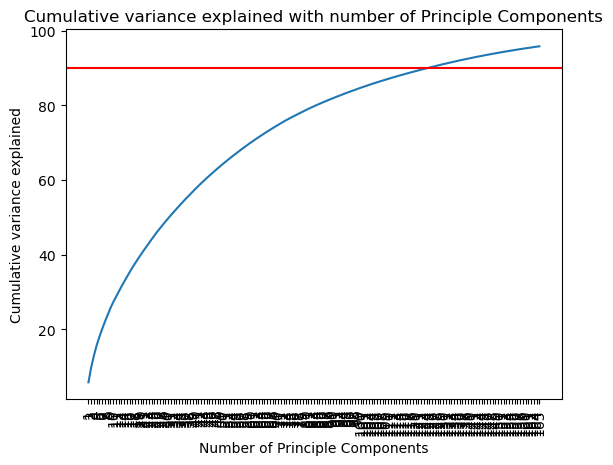

In [21]:
plt.plot(list(np.arange(1,166)),np.cumsum(pca.explained_variance_ratio_*100))
plt.xticks(list(np.arange(1,166)),label=list(np.arange(1,166)))
plt.title("Cumulative variance explained with number of Principle Components")
plt.xlabel("Number of Principle Components")
plt.axhline(y=90,color="red",linestyle="-")
plt.xticks(rotation=90)
plt.ylabel("Cumulative variance explained")
plt.show()

In [22]:
np.cumsum(pca.explained_variance_ratio_*100)

array([ 5.8255401 ,  9.85163588, 13.00447909, 15.76255994, 18.04836185,
       20.11175086, 22.08631514, 23.93042759, 25.69821149, 27.27817962,
       28.68928958, 30.08968538, 31.47833819, 32.8077741 , 34.09273652,
       35.35145228, 36.58826552, 37.74127529, 38.86623974, 39.97589206,
       41.04890249, 42.10179511, 43.14416448, 44.15858049, 45.16488928,
       46.15598891, 47.08186955, 47.99454588, 48.89104353, 49.76390429,
       50.62430304, 51.46054598, 52.28092367, 53.09293408, 53.89786463,
       54.68208076, 55.45105133, 56.21767596, 56.98005609, 57.71765751,
       58.44741825, 59.15905023, 59.85351472, 60.5348822 , 61.1989388 ,
       61.85663509, 62.50821414, 63.14994543, 63.78497   , 64.39670991,
       65.00078631, 65.59945673, 66.18086577, 66.75194724, 67.31789305,
       67.88028644, 68.43625388, 68.98218339, 69.52164674, 70.04040934,
       70.55422714, 71.05968727, 71.55413683, 72.04334453, 72.52026704,
       72.9907179 , 73.4571119 , 73.91797681, 74.36512936, 74.81

In [23]:
#transforming the features into pca components.
#From the above data we understand that 95% of the variance in the 442 features could be explained by 165 PCA Components.

x_train_pca=pca.transform(x_train_scaled)
x_train_pca=pd.DataFrame(x_train_pca)

x_test_pca=pca.transform(x_test_scaled)
x_test_pca=pd.DataFrame(x_test_pca)

data_scaled_pca=pca.transform(data_scaled)
data_scaled_pca=pd.DataFrame(data_scaled)

In [24]:
data_scaled_pca.shape

(1567, 442)

In [25]:
len(y)

1567


**D. Check for multi-collinearity in the data and take necessary action.**

<Axes: >

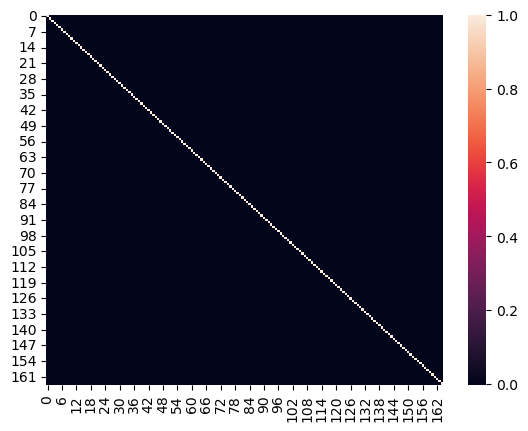

In [26]:
sns.heatmap(x_train_pca.corr())

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    # Calculating VIF
    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)

In [28]:
calc_vif(x_train_pca)

,variables,VIF
0,0,1.000000
1,1,1.000000
2,2,1.000000
3,3,1.000000
4,4,1.000000
5,5,1.000000
6,6,1.000000
7,7,1.000000
8,8,1.000000
9,9,1.000000


We can see from above that the VIF is 1 so there is no correlation between the independent variables <br>
The original dataset is now represented by 165 Principal Components and the principal components are completely independent with each other and hence there is no correlation betweem the independent variables currently

**E. Make all relevant modifications on the data using both functional/logical reasoning/assumptions.**

Below are the modifications that has been made on the original dataset.
- Columns having more than 20% of missing data are dropped from the dataset
- Columns with less than 20% of missing data is imputed with the mean
- Columns having the same value for all the rows i.e, the standard deviation =0 are removed
- The values in each of the columns are on different scales so applied zscore to all the independent variables are standardise the data
- The number of columns is very high in the dataset so we can apply dimensionality reduction using PCA.
- 95% of the variance in the original dataset is represented by 165 PCA components

Hence the original dataset has been reduced to 165 columns and 1567 rows

### 3. Data analysis & visualisation

**A. Perform a detailed univariate Analysis with appropriate detailed comments after each analysis.**

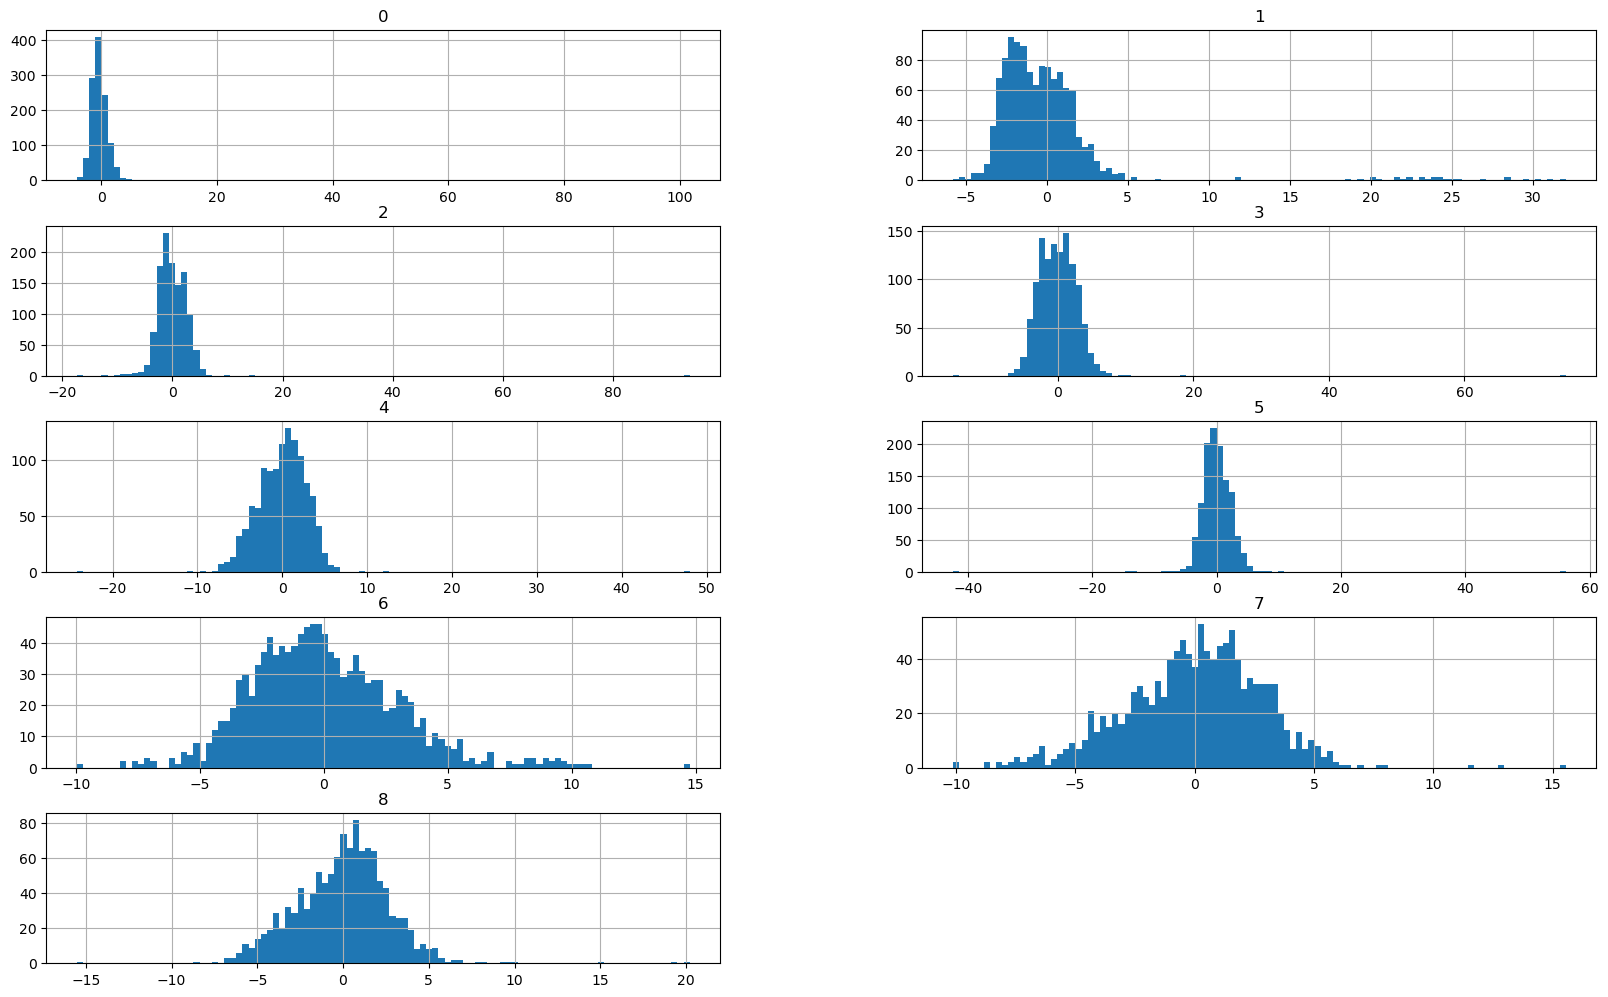

In [29]:
#Plotting the histogram for the first 10 features in the dataset
columns = list(x_train_pca)[0:9] 
x_train_pca[columns].hist(stacked=False, bins=100, figsize=(20,35), layout=(14,2)); 

Observations from the histplot for the first 10 independent variables:
- Distributions are normal with skewness
- Outliers are present for most of the distributions
- Columns 6 and 7 has a higher standard deviation than columns 1 and 2
- colum 6 is slightly right skewed 
- Column 7 and 8 are left skewed 

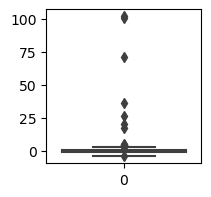

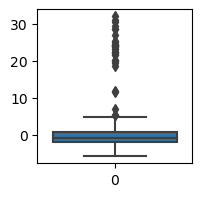

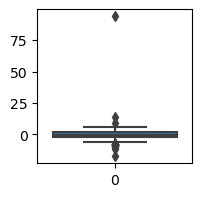

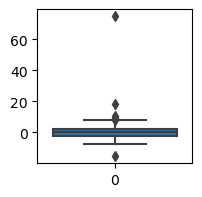

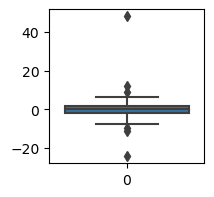

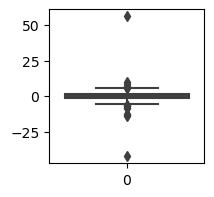

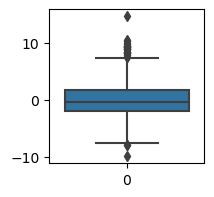

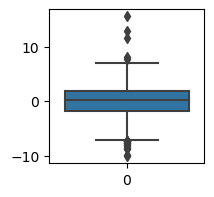

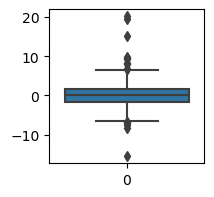

In [30]:
#Plotting the boxplot for the first 10 features in the dataset
for i in columns:
    plt.figure(figsize=(2,2))
    sns.boxplot(x_train_pca[i])
    plt.show();

Observations from the Boxplot of the first 10 independent variables:
- All the features plotted are having outliers
- Outliers are present both above upper fence and below the lower fence
- Max values in most of the columns are very high when compared to the Q3 values or the upper fence

**B. Perform bivariate and multivariate analysis with appropriate detailed comments after each analysis.**

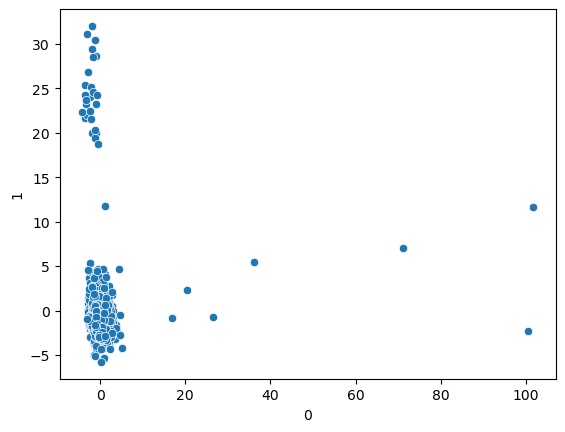

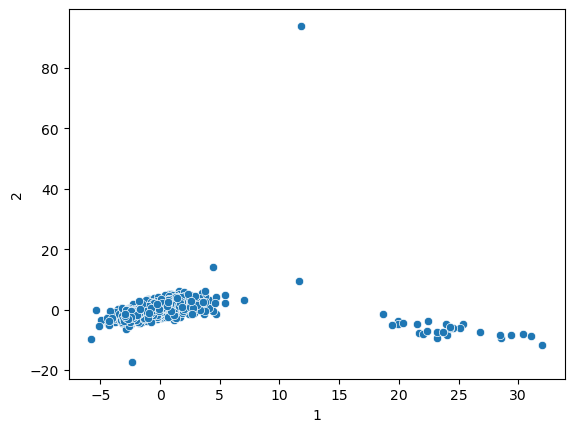

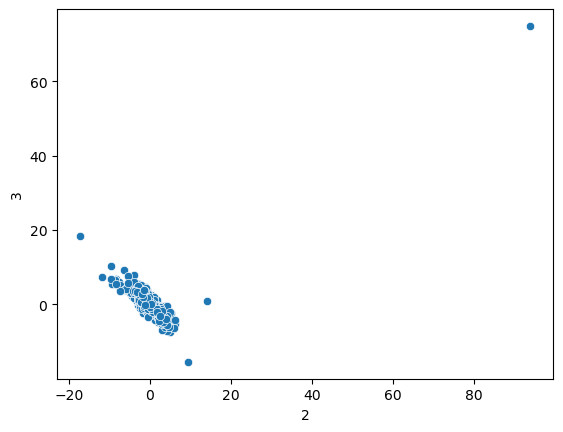

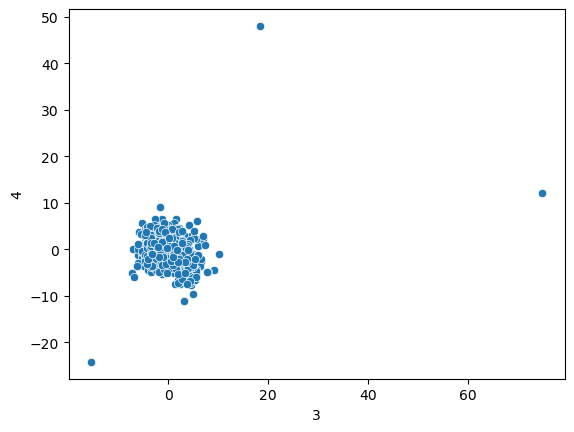

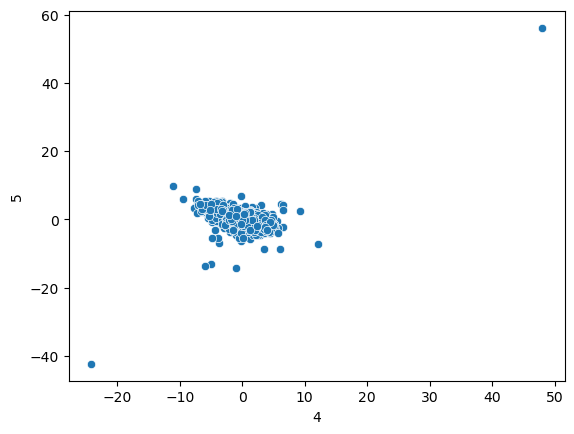

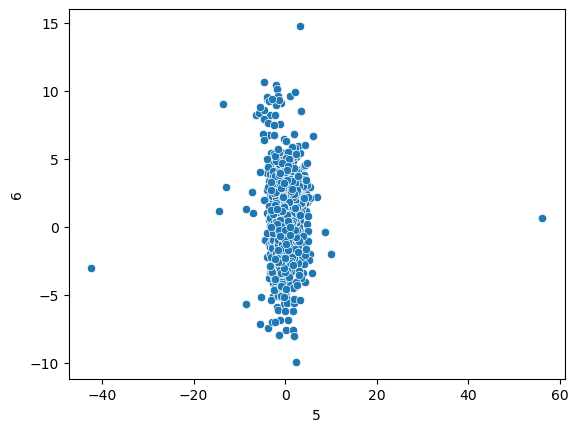

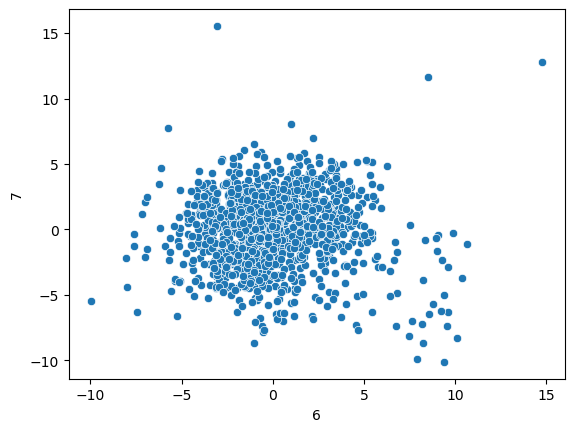

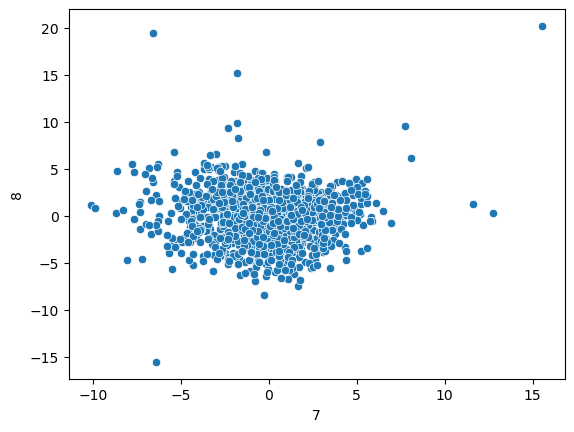

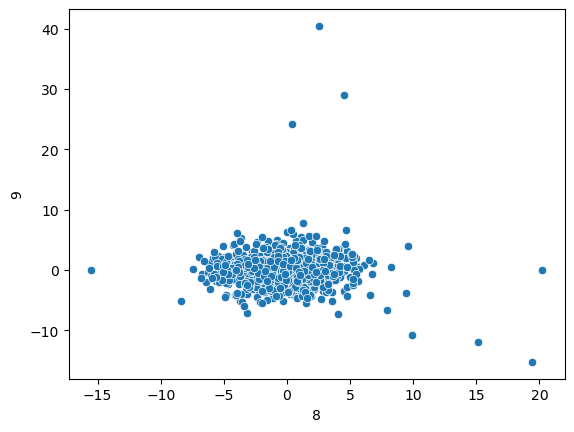

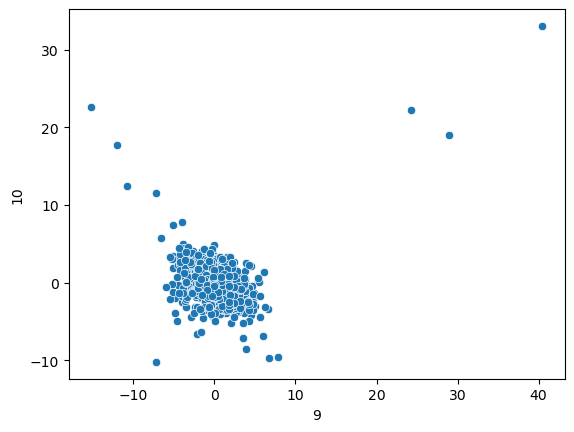

In [31]:
#Scatter plot for the first 10 feature

for x in np.arange(0,10):
    n=x+1
    sns.scatterplot(x_train_pca,x=x,y=n)
    plt.show()

Observations from the scatterplot for the first 10 columns:
- Most of the scatterplots looks like a blob or cloud of datapoints and hence we can say that there is no correlation between the features
- Features have been converted to PCA components and PCA components does not have any correlation between them

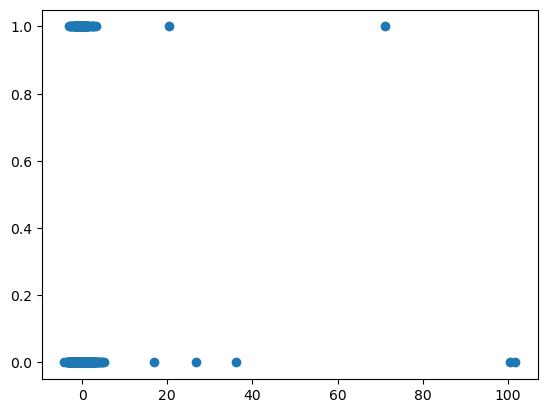

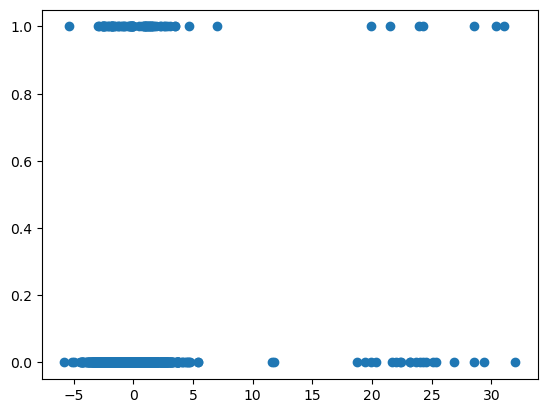

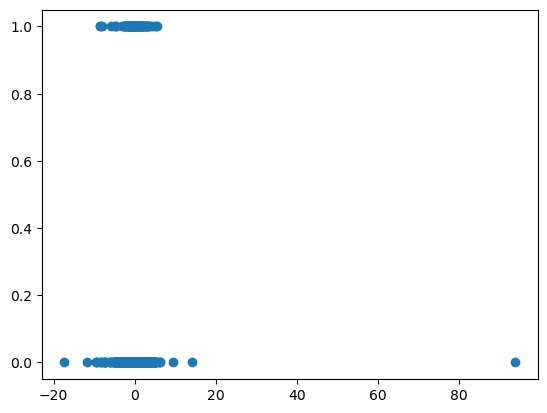

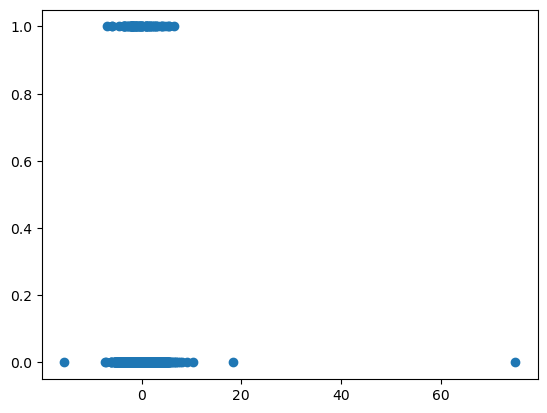

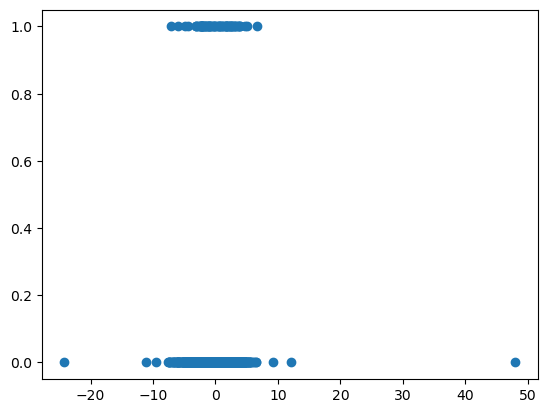

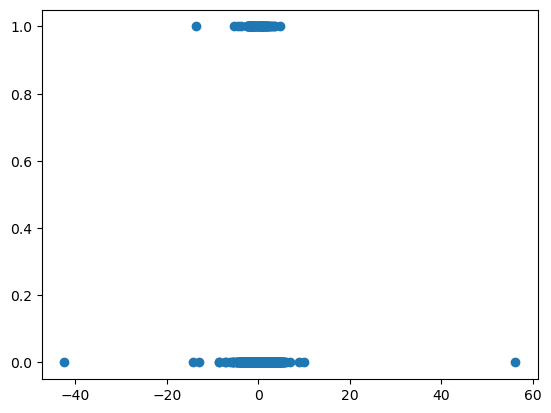

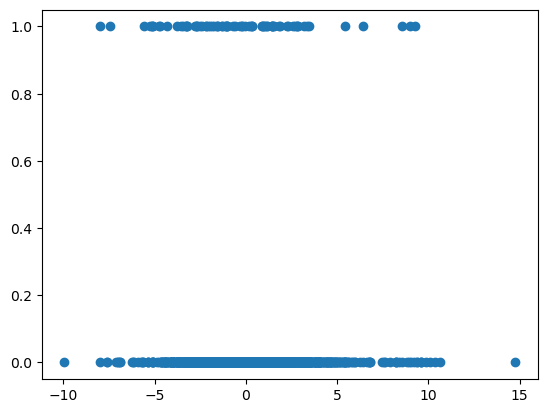

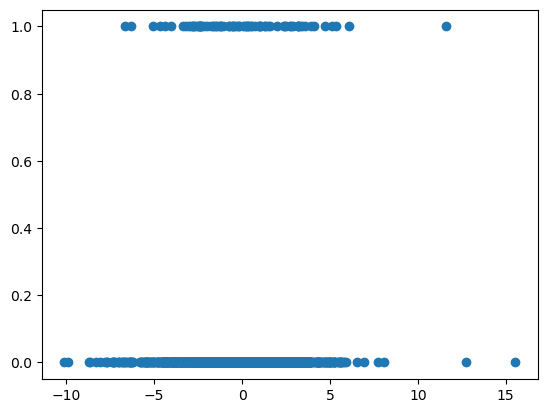

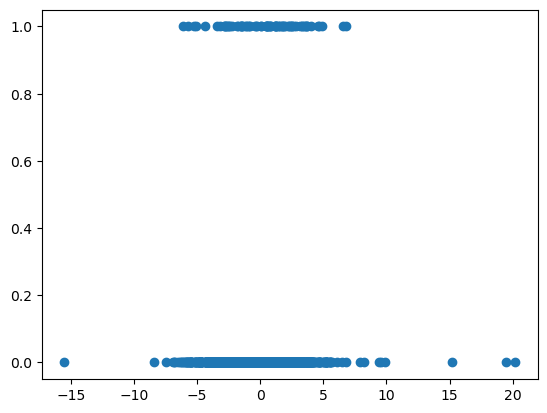

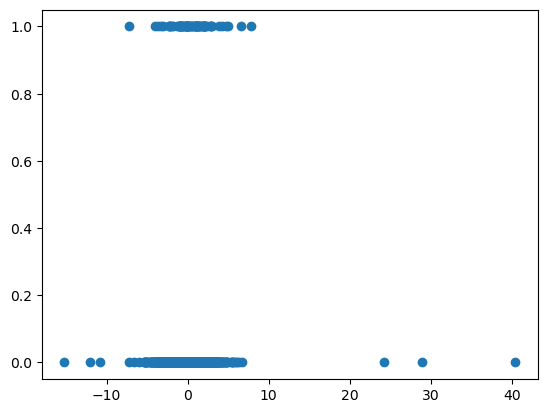

In [32]:
for x in np.arange(0,10):
    plt.scatter(x=x_train_pca[x],y=y_train)
    plt.show()

Above is the scatter plot between the first 10 features and the target variable. <br>
From the plots we cannot infer the relation between the target variable and independent variables. <br>
For each of the independent variables are spread across in the same fashion for each value of the target variable.

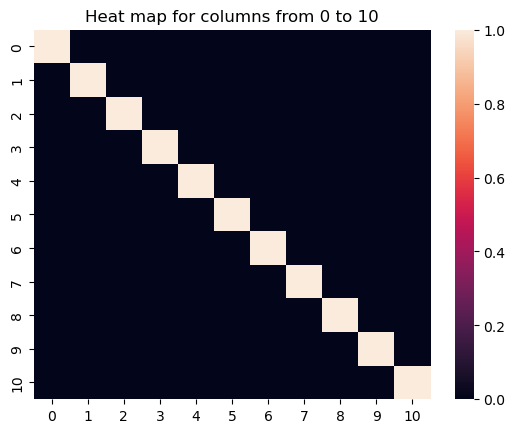

In [33]:
sns.heatmap(x_train_pca.loc[:,:10].corr())
plt.title("Heat map for columns from 0 to 10")
plt.show();

Observations from the heatmap:
- Above heatmap confirms our inference from the scatterplot that the features are not correlated.


The above univariate and bivariate plots shows that there are many outliers in the dataset.
Let us also do an outlier treatment on the training dataset

In [34]:
x_train_pca.columns

RangeIndex(start=0, stop=165, step=1)

From the plots it is visible that there are many outliers in the data, hence let us remove the outliers by 
- imputing the datapoints having values > 90th percentile with the 90th percentile value
- imputing datapoints with values < 10th percentile with the 10th percentile value.

Inorder to prevent dataleakage it we are doing this imputing separately for the training set and the testing set

In [35]:
for i in np.arange(0,164):
    
    q10, q90 = np.quantile(x_train_pca[i], 0.1), np.quantile(x_train_pca[i], 0.9)
    
   
    for j in np.arange(0,1175):
        if x_train_pca[i][j]>q90:
            x_train_pca[i][j]=q90
        elif x_train_pca[i][j]<q10:
            x_train_pca[i][j]=q10
    


In [92]:
x_train_pca.shape

(1175, 165)

In [93]:
for i in np.arange(0,164):
    
    q101, q901 = np.quantile(x_test_pca[i], 0.1), np.quantile(x_test_pca[i], 0.9)
    
   
    for j in np.arange(0,392):
        if x_test_pca[i][j]>q901:
            x_test_pca[i][j]=q901
        elif x_test_pca[i][j]<q101:
            x_test_pca[i][j]=q101
    

### 4. Data pre-processing:

**A. Segregate predictors vs target attributes.**

Inorder to avoid data leakage, the dataset has been divided into predictors and target attributes as part of 2.c

**B. Check for target balancing and fix it if found imbalanced.**

In [36]:
print("Datapoints with class as 0",len(y_train[y_train[:]==0]))
print("Datapoints with class as 1",len(y_train[y_train[:]==1]))

Datapoints with class as 0 1097
Datapoints with class as 1 78


From the above we can infer that the data is clearly imbalanced with majority of the data in the "0" class. <br>
Balancing the data using smote technique

In [37]:
sm = SMOTE(sampling_strategy = 1 ,k_neighbors = 5, random_state=1)   #Synthetic Minority Over Sampling Technique
x_train_bal, y_train_bal = sm.fit_resample(x_train_pca, y_train.ravel())

In [38]:
print("Datapoints with class as 0",len(y_train_bal[y_train_bal[:]==0]))
print("Datapoints with class as 1",len(y_train_bal[y_train_bal[:]==1]))

Datapoints with class as 0 1097
Datapoints with class as 1 1097


The training dataset has been balanced using SMOTE technique

**C. Perform train-test split and standardise the data or vice versa if required.**

train-test split is already done as part of 2.c

**D. Check if the train and test data have similar statistical characteristics when compared with original data.**

Below are the changes made to the original dataset:
- original dataset: data
- train test split: x_train, x_test, y_train, y_test
- Independent variables scaled: x_train_scaled, x_test_scaled
- Independent variables converted to pca: x_train_pca, x_test_pca
- Balanced Training dataset: x_train_bal,y_train_bal


In [39]:
 data.describe().T

,count,mean,std,min,25%,50%,75%,max
0,1567.0,3014.452896,73.480613,2743.2400,2966.66500,3011.840000,3056.540000,3356.3500
1,1567.0,2495.850231,80.227793,2158.7500,2452.88500,2498.910000,2538.745000,2846.4400
2,1567.0,2200.547318,29.380932,2060.6600,2181.09995,2200.955600,2218.055500,2315.2667
3,1567.0,1396.376627,439.712852,0.0000,1083.88580,1287.353800,1590.169900,3715.0417
4,1567.0,4.197013,56.103066,0.6815,1.01770,1.317100,1.529600,1114.5366
6,1567.0,101.112908,6.209271,82.1311,97.93780,101.492200,104.530000,129.2522
7,1567.0,0.121822,0.008936,0.0000,0.12110,0.122400,0.123800,0.1286
8,1567.0,1.462862,0.073849,1.1910,1.41125,1.461600,1.516850,1.6564
9,1567.0,-0.000841,0.015107,-0.0534,-0.01080,-0.001300,0.008400,0.0749
10,1567.0,0.000146,0.009296,-0.0349,-0.00560,0.000400,0.005900,0.0530


In [40]:
x_train.describe().T

,count,mean,std,min,25%,50%,75%,max
0,1175.0,3.015545e+03,74.135970,2743.2400,2968.42000,3013.320000,3057.320000,3356.3500
1,1175.0,2.495323e+03,78.515680,2162.8700,2453.29500,2499.350000,2538.885000,2846.4400
2,1175.0,2.199959e+03,29.803329,2060.6600,2180.70000,2200.547318,2218.055500,2315.2667
3,1175.0,1.390291e+03,428.105435,0.0000,1081.87580,1285.214400,1590.169900,3715.0417
4,1175.0,4.199501e+00,56.125893,0.6815,1.02030,1.317700,1.529100,1114.5366
6,1175.0,1.011319e+02,6.160578,82.1311,98.11330,101.587800,104.521100,129.2522
7,1175.0,1.219267e-01,0.008196,0.0000,0.12110,0.122400,0.123800,0.1286
8,1175.0,1.464220e+00,0.074077,1.1910,1.41025,1.463400,1.520600,1.6564
9,1175.0,-7.772264e-04,0.015150,-0.0534,-0.01080,-0.001300,0.008400,0.0749
10,1175.0,2.224219e-04,0.009101,-0.0329,-0.00540,0.000500,0.005900,0.0396


In [41]:
x_test.describe().T

,count,mean,std,min,25%,50%,75%,max
0,392.0,3.011178e+03,71.473061,2787.4900,2964.472500,3006.060000,3055.275000,3266.550000
1,392.0,2.497431e+03,85.238923,2158.7500,2452.165000,2498.010000,2538.447500,2809.790000
2,392.0,2.202312e+03,28.039637,2113.0778,2184.763900,2201.066700,2218.591675,2315.266700
3,392.0,1.414617e+03,472.908201,812.1294,1084.636050,1291.851700,1590.433300,3619.739700
4,392.0,4.189555e+00,56.106255,0.7217,1.017700,1.300400,1.552100,1112.160000
6,392.0,1.010560e+02,6.360648,82.2467,97.820550,101.112908,104.586700,123.424400
7,392.0,1.215061e-01,0.010861,0.0000,0.121000,0.122300,0.123925,0.127600
8,392.0,1.458789e+00,0.073105,1.2005,1.414950,1.457450,1.508650,1.648600
9,392.0,-1.032248e-03,0.014994,-0.0410,-0.010600,-0.001250,0.008250,0.046800
10,392.0,-8.406696e-05,0.009867,-0.0349,-0.005800,0.000173,0.005900,0.053000


Observations on comparing the original dataset with the train test datasets:
- 1567 datapoints in the dataset "data" has been divided into "1175" and "392" datapoints in the train and test datasets respectively
- Mean, Median and standard deviation for all the 3 datasets are very similar across the datapoints.
- Q1 and Q3 for the datasets also are very close for all the 3 datasets

The datasets are having the similar statistical characteristics

### 5. Model training, testing and tuning

**A. Use any Supervised Learning technique to train a model.**

In [42]:
DTree = DecisionTreeClassifier(random_state=1)
DTree.fit(x_train_bal,y_train_bal)

#predict on test
y_predict_DTree = DTree.predict(x_test_pca)

In [43]:
DTree.score(x_train_bal,y_train_bal)

1.0

In [94]:
DTree.score(x_test_pca,y_test)

0.8061224489795918

In [95]:
y_predict_DTree = DTree.predict(x_test_pca)

In [96]:
print("Classification Report")
print(metrics.classification_report(y_test,y_predict_DTree,labels=[0, 1]))

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       366
           1       0.10      0.23      0.14        26

    accuracy                           0.81       392
   macro avg       0.52      0.54      0.51       392
weighted avg       0.88      0.81      0.84       392



- Accuracy of the model with training data is 100% whcih is a clear overfit and when using this overfit model on the testing data, accuracy for the model reduced to 80
- Though we have balanced the dataset, we can observe that the performance of the model for the Class 1 is not high.
- Performance score of Claqss 0 with test data is good and hence the accuracy is high. 
- Model is good at predicting Class 0 correctly but needs improvement on the Class 1 prediction

**B. Use cross validation techniques**

In [46]:
#Let us use the entire dataset for applying cross validation techniques
#K-fold
kf = KFold(n_splits=50)
kfold_score = cross_val_score(DTree,data_scaled_pca,y,cv=kf)

In [47]:
print("The cross validation scores of k-fold method with 50 folds is",kfold_score)

The cross validation scores of k-fold method with 50 folds is [0.71875    0.53125    0.65625    0.75       0.78125    0.8125
 0.6875     0.6875     0.84375    0.8125     0.75       0.875
 0.84375    0.9375     0.84375    0.875      0.96875    0.93548387
 0.90322581 0.96774194 0.93548387 0.93548387 0.96774194 0.87096774
 0.93548387 0.93548387 0.93548387 0.90322581 0.87096774 0.87096774
 0.96774194 0.93548387 0.96774194 0.93548387 0.87096774 0.93548387
 0.80645161 0.83870968 0.87096774 0.80645161 0.83870968 0.96774194
 0.48387097 0.87096774 0.93548387 0.96774194 0.90322581 0.93548387
 0.90322581 0.96774194]


In [48]:
kfold_score_mean = kfold_score.mean()
print("The min accuracy from k-fold CV is",min(kfold_score))
print("The max accuracy from k-fold CV is", max(kfold_score))
print("The mean cross validation scores of k-fold method with 5 folds is",kfold_score_mean)

The min accuracy from k-fold CV is 0.4838709677419355
The max accuracy from k-fold CV is 0.96875
The mean cross validation scores of k-fold method with 5 folds is 0.8610483870967743


In [49]:
#Stratified K-Fold method
skfold = StratifiedKFold(n_splits=50)
skfold_score = cross_val_score(DTree,data_scaled_pca,y,cv=skfold)
skfold_score_mean=skfold_score.mean()

In [50]:
print("The cross validation scores of sk-fold method with 50 folds is",skfold_score)
print("The min accuracy from k-fold CV is",min(skfold_score))
print("The max accuracy from k-fold CV is", max(skfold_score))
print("The mean cross validation scores of k-fold method with 5 folds is",skfold_score_mean)

The cross validation scores of sk-fold method with 50 folds is [0.75       0.6875     0.78125    0.78125    0.84375    0.71875
 0.6875     0.8125     0.8125     0.84375    0.78125    0.84375
 0.78125    0.84375    0.875      0.875      0.96875    0.93548387
 0.96774194 0.90322581 0.87096774 0.93548387 0.93548387 0.87096774
 0.83870968 0.83870968 0.90322581 0.87096774 0.90322581 0.90322581
 0.83870968 0.90322581 0.90322581 0.93548387 0.87096774 0.90322581
 0.77419355 0.90322581 0.80645161 0.61290323 0.87096774 0.83870968
 0.5483871  0.87096774 0.90322581 0.93548387 0.90322581 0.93548387
 0.87096774 0.90322581]
The min accuracy from k-fold CV is 0.5483870967741935
The max accuracy from k-fold CV is 0.96875
The mean cross validation scores of k-fold method with 5 folds is 0.8479435483870968


In [51]:
#Leave one out
#loocv = LeaveOneOut()
#loocv_score = cross_val_score(DTree,data_scaled_pca,y,cv=loocv)
#loocv_score_mean=loocv_score.mean()

In [52]:
#print("The min accuracy from k-fold CV is",min(loocv_score))
#print("The max accuracy from k-fold CV is", max(loocv_score))
#print("The mean cross validation scores of k-fold method with 5 folds is",loocv_score_mean)

**C. Apply hyper-parameter tuning techniques to get the best accuracy**

Below are the hyperparameter tuning techniques that we are going to implement on the decision tree model
- Grid Search
- Random Search

In [53]:
# Grid search hyper parameter tuning
hyper_params = {
    'max_depth': [20,50,100,150],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
DTree_g=DecisionTreeClassifier()
DTree_grid=GridSearchCV(DTree_g,hyper_params,cv=10)
DTree_grid.fit(x_train_bal,y_train_bal)

print("tuned hyperparameters :(best parameters) ",DTree_grid.best_params_)
print("accuracy :",DTree_grid.best_score_)

tuned hyperparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 50, 'min_samples_leaf': 5}
accuracy : 0.8929057700290576


In [97]:
y_pred_DTree_grid=DTree_grid.predict(x_test_pca)
print(metrics.classification_report(y_test,y_pred_DTree_grid,labels=[0, 1]))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91       366
           1       0.14      0.27      0.18        26

    accuracy                           0.84       392
   macro avg       0.54      0.58      0.55       392
weighted avg       0.89      0.84      0.86       392



In [56]:
# Random search hyper parameter tuning

hyper_params = {
    'max_depth': np.arange(50,150).tolist()[0::2],
    'min_samples_leaf':np.arange(5,15).tolist()[0::2],
    'criterion': ["gini", "entropy"]
}
DTree_r=DecisionTreeClassifier()
DTree_rand = RandomizedSearchCV(DTree_r,hyper_params,cv=10,random_state = 1)
DTree_rand.fit(x_train_bal,y_train_bal)

print("tuned hyperparameters :(best parameters) ",DTree_rand.best_params_)
print("accuracy :",DTree_rand.best_score_)


tuned hyperparameters :(best parameters)  {'min_samples_leaf': 5, 'max_depth': 86, 'criterion': 'gini'}
accuracy : 0.8837920298879203


In [98]:
y_pred_DTree_rand=DTree_rand.predict(x_test_pca)

In [99]:
print("Classification Report")
print(metrics.classification_report(y_test,y_pred_DTree_rand,labels=[0, 1]))

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       366
           1       0.12      0.27      0.17        26

    accuracy                           0.82       392
   macro avg       0.53      0.56      0.53       392
weighted avg       0.89      0.82      0.85       392



**D. Use any other technique/method which can enhance the model performance.**

Below are the treatments that are already done to the data:
- Scaled the data using zscore
- Dimensionality curse solved using PCA by representing the 443 features using 165 PCA Components
- Target balancing done to the data using SMOTE
- Outlier treatment

**E. Display and explain the classification report in detail**

In [60]:
def Classification_Report(Model,x_test,y_test):
    y_pred=Model.predict(x_test)
    print("Classification Report for the Model",Model)
    print(metrics.classification_report(y_test,y_pred,labels=[0, 1]))

In [114]:
Classification_Report(DTree_grid,x_test_pca,y_test)

Classification Report for the Model GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [20, 50, 100, 150],
                         'min_samples_leaf': [5, 10, 20, 50, 100]})
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       366
           1       0.14      0.27      0.18        26

    accuracy                           0.84       392
   macro avg       0.54      0.58      0.55       392
weighted avg       0.89      0.84      0.86       392



In [115]:
Classification_Report(DTree_rand,x_test_pca,y_test)

Classification Report for the Model RandomizedSearchCV(cv=10, estimator=DecisionTreeClassifier(),
                   param_distributions={'criterion': ['gini', 'entropy'],
                                        'max_depth': [50, 52, 54, 56, 58, 60,
                                                      62, 64, 66, 68, 70, 72,
                                                      74, 76, 78, 80, 82, 84,
                                                      86, 88, 90, 92, 94, 96,
                                                      98, 100, 102, 104, 106,
                                                      108, ...],
                                        'min_samples_leaf': [5, 7, 9, 11, 13]},
                   random_state=1)
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       366
           1       0.12      0.27      0.17        26

    accuracy                           0.82       392
   macro avg       0.53      0.56      0

Observations from the performance of the models after tuning the parameters
- Grid search and random search was performed for the basic decision tree model by tuning the below hyper parameters
     - criterion
     - max_depth
     - min_samples_leaf
- Both Grid search and random search has selected the criterion as gini and min_samples_leaf =5
- When analysing the precision and recall for the failed scenario (Class 1), decision tree with the hyper parameters tuned by grid search  and random search are having the almost the same performances with grid search having a slightly higher precision.
- Overall accuracy for the model is slightly higher for grid search with an accuracy of 84% when compared to the same of random search which is giving an accuracy of 82%
- Recall,precision and F2-score for the Pass scenarios is slightly higher for grid search


**F. Apply the above steps for all possible models that you have learnt so far.**

In [104]:
#Logistic Regression
LogReg = LogisticRegression(random_state=1)
LogReg.fit(x_train_bal,y_train_bal)
#predict on test
Classification_Report(LogReg,x_test_pca,y_test)

Classification Report for the Model LogisticRegression(random_state=1)
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       366
           1       0.05      0.12      0.07        26

    accuracy                           0.81       392
   macro avg       0.49      0.49      0.48       392
weighted avg       0.87      0.81      0.84       392



In [64]:
#tuning the hyper parameters for Logistic Regression using grid search
hyper_params={"C":[0.01,0.1,1.0], 
              "max_iter":[100,200,300],
              "solver":["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]
              }

Logreg_g=LogisticRegression()
LogReg_grid = GridSearchCV(Logreg_g,hyper_params,cv=10)
LogReg_grid.fit(x_train_bal,y_train_bal)

print("tuned hyperparameters :(best parameters) ",LogReg_grid.best_params_)
print("accuracy :",LogReg_grid.best_score_)


tuned hyperparameters :(best parameters)  {'C': 1.0, 'max_iter': 200, 'solver': 'saga'}
accuracy : 0.9143171440431714


In [105]:
Classification_Report(LogReg_grid,x_test_pca,y_test)

Classification Report for the Model GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1.0], 'max_iter': [100, 200, 300],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']})
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       366
           1       0.05      0.12      0.07        26

    accuracy                           0.81       392
   macro avg       0.49      0.49      0.48       392
weighted avg       0.87      0.81      0.84       392



In [106]:
# using Gaussian algorithm from Naive Bayes
Gaussnb = GaussianNB()
Gaussnb.fit(x_train_bal,y_train_bal)
Classification_Report(Gaussnb,x_test_pca,y_test)

Classification Report for the Model GaussianNB()
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       366
           1       0.18      0.08      0.11        26

    accuracy                           0.92       392
   macro avg       0.56      0.53      0.53       392
weighted avg       0.89      0.92      0.90       392



In [67]:
#tuning the hyper parameters for Gaussian NB using grid search
hyper_params= {
    
    "var_smoothing": [0.00000001, 0.000000001, 0.00000001]
}

gaussnb_g=GaussianNB()
Gaussnb_grid = GridSearchCV(gaussnb_g,hyper_params,cv=10)
Gaussnb_grid.fit(x_train_bal,y_train_bal)

print("tuned hyperparameters :(best parameters) ",Gaussnb_grid.best_params_)
print("accuracy :",Gaussnb_grid.best_score_)


tuned hyperparameters :(best parameters)  {'var_smoothing': 1e-08}
accuracy : 0.8811062681610627


In [107]:
Classification_Report(Gaussnb_grid,x_test_pca,y_test)

Classification Report for the Model GridSearchCV(cv=10, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1e-08, 1e-09, 1e-08]})
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       366
           1       0.18      0.08      0.11        26

    accuracy                           0.92       392
   macro avg       0.56      0.53      0.53       392
weighted avg       0.89      0.92      0.90       392



In [108]:
Knn = KNeighborsClassifier()
Knn.fit(x_train_bal,y_train_bal)
Classification_Report(Knn,x_test_pca,y_test)

Classification Report for the Model KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.97      0.23      0.38       366
           1       0.08      0.88      0.14        26

    accuracy                           0.28       392
   macro avg       0.52      0.56      0.26       392
weighted avg       0.91      0.28      0.36       392



In [70]:
hyper_params={ 'n_neighbors' : [5,7,9,11,13,15],
               'weights' : ['uniform','distance'],
               'metric' : ['minkowski','euclidean','manhattan']}
knn_g=KNeighborsClassifier()
Knn_grid = GridSearchCV(knn_g,hyper_params,cv=10)
Knn_grid.fit(x_train_bal,y_train_bal)

print("tuned hyperparameters :(best parameters) ",Knn_grid.best_params_)
print("accuracy :",Knn_grid.best_score_)


tuned hyperparameters :(best parameters)  {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
accuracy : 0.6171440431714404


In [109]:
Classification_Report(Knn_grid,x_test_pca,y_test)

Classification Report for the Model GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['minkowski', 'euclidean', 'manhattan'],
                         'n_neighbors': [5, 7, 9, 11, 13, 15],
                         'weights': ['uniform', 'distance']})
              precision    recall  f1-score   support

           0       0.96      0.30      0.46       366
           1       0.08      0.81      0.14        26

    accuracy                           0.34       392
   macro avg       0.52      0.56      0.30       392
weighted avg       0.90      0.34      0.44       392



In [110]:
Svm = svm.SVC()
Svm.fit(x_train_bal,y_train_bal)
Classification_Report(Svm,x_test_pca,y_test)

Classification Report for the Model SVC()
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       366
           1       1.00      0.04      0.07        26

    accuracy                           0.94       392
   macro avg       0.97      0.52      0.52       392
weighted avg       0.94      0.94      0.91       392



In [73]:
hyper_params = {'C': [0.1,1, 10], 'gamma': [1,0.1,0.25]}
Svm_grid = GridSearchCV(svm.SVC(),hyper_params,refit=True,verbose=2)
Svm_grid.fit(x_train_bal,y_train_bal)

print("tuned hyperparameters :(best parameters) ",Svm_grid.best_params_)
print("accuracy :",Svm_grid.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END .....................................C=0.1, gamma=1; total time=   0.8s
[CV] END .....................................C=0.1, gamma=1; total time=   0.8s
[CV] END .....................................C=0.1, gamma=1; total time=   0.8s
[CV] END .....................................C=0.1, gamma=1; total time=   0.8s
[CV] END .....................................C=0.1, gamma=1; total time=   0.8s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.8s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.9s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.8s
[CV] END ...................................C=0.1, gamma=0.1; total time=   1.0s
[CV] END ...................................C=0.1, gamma=0.1; total time=   0.9s
[CV] END ..................................C=0.1, gamma=0.25; total time=   0.9s
[CV] END ..................................C=0.1,

In [111]:
Classification_Report(Svm_grid,x_test_pca,y_test)

Classification Report for the Model GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.25]},
             verbose=2)
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       366
           1       0.00      0.00      0.00        26

    accuracy                           0.93       392
   macro avg       0.47      0.50      0.48       392
weighted avg       0.87      0.93      0.90       392



### 6. Post Training and Conclusion

**A. Display and compare all the models designed with their train and test accuracies.**

In [112]:
Models=[DTree,DTree_grid,DTree_rand,LogReg,LogReg_grid,Gaussnb,Gaussnb_grid,Knn,Knn_grid,Svm_grid]
Precision_Testing=[]
Precision_Training=[]
Recall_Testing=[]
Recall_Training=[]
F1_score_Testing=[]
F1_score_Training=[]
Accuracy_Testing=[]
Accuracy_Training=[]

for model in Models:
    y_train_pred=model.predict(x_train_bal)
    y_test_pred=model.predict(x_test_pca)
    report_test=metrics.classification_report(y_test, y_test_pred, labels=[1, 0],output_dict=True)
    report_train=metrics.classification_report(y_train_bal, y_train_pred, labels=[1, 0],output_dict=True)
    Precision_Testing.append("{:.2f}".format(report_test["1"]["precision"]))
    Precision_Training.append("{:.2f}".format(report_train["1"]["precision"]))
    Recall_Testing.append("{:.2f}".format(report_test["1"]["recall"]))
    Recall_Training.append("{:.2f}".format(report_train["1"]["recall"]))
    F1_score_Testing.append("{:.2f}".format(report_test["1"]["f1-score"]))
    F1_score_Training.append("{:.2f}".format(report_train["1"]["f1-score"]))
    Accuracy_Testing.append("{:.2f}".format(report_test["accuracy"]))
    Accuracy_Training.append("{:.2f}".format(report_train["accuracy"]))

In [113]:
col_names=["Precision_Testing","Precision_Training","Recall_Testing","Recall_Training","F1_score_Testing","F1_score_Training","Accuracy_Testing","Accuracy_Training"]
data=pd.DataFrame(data=[Precision_Testing,Precision_Training,Recall_Testing,Recall_Training,F1_score_Testing,F1_score_Training,Accuracy_Testing,Accuracy_Training],columns=["DTree","DTree_grid","DTree_rand","LogReg","LogReg_grid","Gaussnb","Gaussnb_grid","Knn","Knn_grid","Svm_grid"],
                 index=col_names)
data

,DTree,DTree_grid,DTree_rand,LogReg,LogReg_grid,Gaussnb,Gaussnb_grid,Knn,Knn_grid,Svm_grid
Precision_Testing,0.10,0.14,0.12,0.05,0.05,0.18,0.18,0.08,0.08,0.00
Precision_Training,1.00,0.98,0.98,0.91,0.91,0.95,0.95,0.61,0.63,1.00
Recall_Testing,0.23,0.27,0.27,0.12,0.12,0.08,0.08,0.88,0.81,0.00
Recall_Training,1.00,0.96,0.97,0.99,0.99,0.81,0.81,1.00,1.00,1.00
F1_score_Testing,0.14,0.18,0.17,0.07,0.07,0.11,0.11,0.14,0.14,0.00
F1_score_Training,1.00,0.97,0.97,0.95,0.95,0.87,0.87,0.75,0.77,1.00
Accuracy_Testing,0.81,0.84,0.82,0.81,0.81,0.92,0.92,0.28,0.34,0.93
Accuracy_Training,1.00,0.97,0.97,0.95,0.95,0.88,0.88,0.68,0.70,1.00


Note: The precision,recall and F1-score mentioned above are for the label 1.
- class 1 is the minority class in the original data
- From the problem statement we understand that it is important to find out if the product has failed the test.

**B. Select the final best trained model along with your detailed comments for selecting this model**

From the models that has been trained we can infer that the best model is 
"DTree_grid"

- Overall accuracy for the decision tree with grid is 97% for training and 84% for testing
- In most of the models we can see that the training accuracy is not very less except for knn, this is because accuracy takes into consideration the true positives and true negatives
- Class 0 is the majority class hence the precision, recall for Class 0 is high which contributes for the overall increase in the accuracy for the model
- precision and recall for class 1 is highest for DTree_grid without compromising the accuracy which means that the precision and recall for Class 0 is not affected much.
- For the model Knn and knn_grid we can see that the recall for Class 1 in testing is very high but here there is a huge compromise done on the same for the Class 0 as well because the overall accuracy for the model in testing for KNN and KNN_grid is 28% and 34% repectivly which is very less.

For the above reasons we can choose the final model to be "DTree_grid"

**C. Pickle the selected model for future use.**

In [77]:
pickle.dump(DTree_grid, open('final_model.pkl','wb'))

The final model selected "DTree_grid" has been pickled and stored into the file "final_model.pkl"

**D. Write your conclusion on the results.**

Conclusions on the results:
* The input dataset consisted of 1597 rows and 592 columns and hence we can say it had a curse of dimensionality
* Preprocessing steps done on the data are:
  * Missing value treatment:
    * Deleting columns with more than 20% of the data missing
    * Imputing the columns mean where the % of missing values is less than 20%                        
   * Standardising the independent variables using zscalar
   * Applying PCA to treat the curse of dimensionality - 95% of variance in the 443 independent variables were converted to 165 PCA Components
   * Training dataset was highly imbalanced, SMOTE technique was used to balance the training dataset
   * Outlier treatment was done on the testing dataset and the training dataset separately inorder to avoid data leakage. Capping was done at the 90th percentile and the 10th percentile for all the features as an outlier treatment
* The final dataset after the pre processing was used for creating the below models
  * DTree - Simple Decision Tree 
  * DTree_grid - Decision Tree with hyperparameter tuning using grid search
  * DTree_rand - Decision Tree with hyperparameter tuning using random  search
  * LogReg - Simple Logistic Regression model
  * LogReg_grid -Logistic Regression model with hyperparameter tuning using grid search
  * Gaussnb -Simple NaiveBase using Gaussian model
  * Gaussnb_grid - NaiveBase using Gaussian model with hyperparameter tuning using grid search
  * Knn - KNN Model
  * Knn_grid - KNN Model with hyper parameter tuning using grid search
  * Svm_grid - SVM Model with hyper parameter tuning using grid search
* Training accuracies for all the models were above 70% with simple DTree having an overfit on the training data
* Testing accuracies were the least for the KNN models
* The datasets were imbalanced with the minority class represented by Class 1, though the target balancing was done using SMOTE technique, we can see that the performance measures for the testing data for Class 1 is not high
* The final model was selected on the basis of the performance measures for the Class 1. Decision Tree model with hyper parameters tuned using grid search was selected
* Though the performance for the Class 1 is not very high, that was the highest among the models created without compromising on the performance on Class 0
                